# Cantilever with a Triangular Load -- Anastruct PlaneSections EulerBeam

Same problem as `Cantilever_Triangular_Load.ipynb` (which uses anaStruct), solved with
[PlaneSections](https://planesections.readthedocs.io/en/stable/index.html) so the two can
be cross-checked against each other and against the closed form.

**Problem.** A 9 m cantilever, built in at the left end, carrying a distributed load of
**270 N/m at the root (x = 0)** falling linearly to **0 N/m at the free tip (x = 9 m)**.


![](assets/cantileverBeam.jpg)

**Units.** Newtons and metres throughout (N, m, N*m).


**Section.** Unlike the anaStruct notebook -- which normalized `EI` to 1 -- this one uses
a **real section** (steel, 300 x 200 mm rectangle), because that is what PlaneSections is
built around and it lets `plotDisp` report millimetres. Reactions, shear and moment are
statically determinate and do not depend on the section at all. Deflections are reported
**both** in mm and as `delta * EI`, so they can be compared directly with the anaStruct
notebook's normalized numbers.

> **Note on versions.** This notebook targets **planesections 1.4.2**, which switched
> its solver backend from OpenSeesPy to PyNiteFEA. Your existing
> `Beam_bending_shear_displacement_PlaneSections.ipynb` uses `ps.OpenSeesAnalyzer2D`,
> which **no longer exists** in 1.4.2 -- it is now `ps.PyNiteAnalyzer2D`. See the
> "API notes" section at the bottom for the other differences worth knowing.

In [1]:
# !pip install planesections

import numpy as np
import matplotlib.pyplot as plt
import planesections as ps

%matplotlib inline

In [2]:
L  = 9.0      # span                                  [m]
q0 = 270.0    # load intensity at the root, 0 at the tip [N/m]

# Steel rectangular section, 300 deep x 200 wide.
E = 200e9     # [Pa]
d = 0.300     # [m]
w = 0.200     # [m]
section = ps.SectionRectangle(E=E, d=d, w=w)

EI = section.E * section.Iz
print(f"Iz = {section.Iz:.6e} m^4     EI = {EI:.4e} N*m^2")

W     = 0.5 * q0 * L   # resultant of the triangular load  [N]
x_bar = L / 3.0        # its line of action, from the root [m]
print(f"resultant W = {W:.1f} N, acting at x = {x_bar:.3f} m from the root")

Iz = 4.500000e-04 m^4     EI = 9.0000e+07 N*m^2
resultant W = 1215.0 N, acting at x = 3.000 m from the root


## Build the beam

PlaneSections 1.4.2 has **`addLinLoadVertical(x1, x2, [q_start, q_end])`** for a linearly
varying load, so the taper is applied exactly -- no need to approximate it with strips.
(The older `addDistLoadVertical` used in your other PlaneSections notebook takes a single
constant `q`; the last section of this notebook shows what it costs to fall back on it.)

Nodes are placed every 0.1 m. Node spacing does **not** affect accuracy here -- PyNite
handles the linear element load exactly, so nodal results are exact regardless -- it only
controls how finely the diagrams are drawn and which stations you can read off directly.

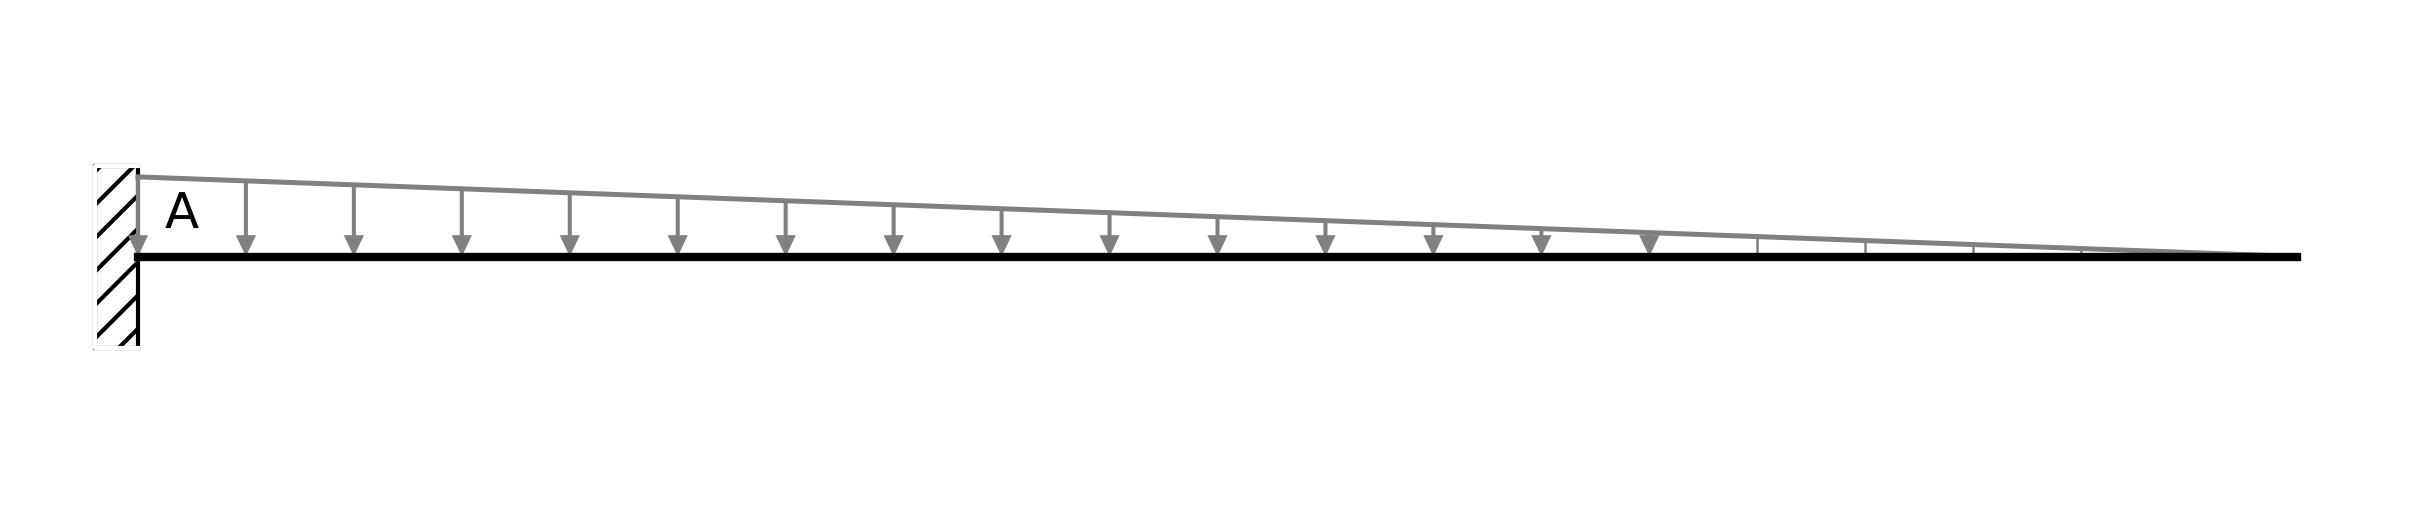

In [3]:
x_nodes = np.linspace(0, L, 91)   # every 0.1 m

beam = ps.EulerBeam2D(x_nodes, section=section)

# Built-in (fixed) support at the root: ux, uy and rotation all restrained.
beam.setFixity(0.0, ps.FixityTypes2D.getFixed(), label="A")

# Triangular load: -270 N/m at the root falling to 0 N/m at the tip. Negative = downward.
beam.addLinLoadVertical(0, L, [-q0, 0.0], label="q")

ps.plotBeamDiagram(beam)
plt.show()

In [4]:
analysis = ps.PyNiteAnalyzer2D(beam)
analysis.runAnalysis()

# Reactions live on the restrained node as [Fx, Fy, M].
Fx_r, Fy_r, M_r = beam.nodes[0].rFrc

print(f"vertical reaction  Fy = {Fy_r:10.3f} N     (upward)")
print(f"fixing moment       M = {M_r:10.3f} N*m   (hogging)")

vertical reaction  Fy =   1215.000 N     (upward)
fixing moment       M =   3645.000 N*m   (hogging)


## Reading results at the nodes

`getSFD()` and `getBMD()` return arrays of length `2 * Nnodes`: each node appears **twice**,
holding the value just to its left and just to its right, so that jumps at point loads
draw correctly. Element `0` is therefore the baseline in front of the support, **not** the
shear at `x = 0`.

Taking `[1::2]` picks the right-hand value at each node, which is the one you want.

In [5]:
def node_results(beam):
    """Per-node x, shear, moment, deflection and rotation as plain arrays.

    getSFD()/getBMD() double up every node (left value, right value) so that jumps at
    point loads plot correctly; [1::2] takes the right-hand value at each node.
    """
    xs, V = beam.getSFD()
    _,  M = beam.getBMD()
    uy, _ = ps.getVertDisp(beam)      # note: returns (disp, xcoords) in that order
    rot, _ = ps.getDisp(beam, 2)

    return {
        "x":   np.asarray(xs)[1::2],
        "V":   np.asarray(V)[1::2],
        "M":   np.asarray(M)[1::2],
        "uy":  np.asarray(uy),
        "rot": np.asarray(rot),
    }


r = node_results(beam)

print(f"max shear   |V| = {abs(r['V']).max():10.3f} N      at x = {r['x'][np.argmax(abs(r['V']))]:.2f} m")
print(f"max moment  |M| = {abs(r['M']).max():10.3f} N*m    at x = {r['x'][np.argmax(abs(r['M']))]:.2f} m")
print()
print(f"tip deflection  = {r['uy'][-1] * 1000:10.4f} mm     ({r['uy'][-1] * EI:12.3f} as delta*EI)")
print(f"tip rotation    = {r['rot'][-1] * 1000:10.4f} mrad   ({r['rot'][-1] * EI:12.3f} as phi*EI)")

max shear   |V| =   1215.000 N      at x = 0.00 m
max moment  |M| =   3645.000 N*m    at x = 0.00 m

tip deflection  =    -0.6561 mm     (  -59049.000 as delta*EI)
tip rotation    =    -0.0911 mrad   (   -8201.250 as phi*EI)


## Diagrams

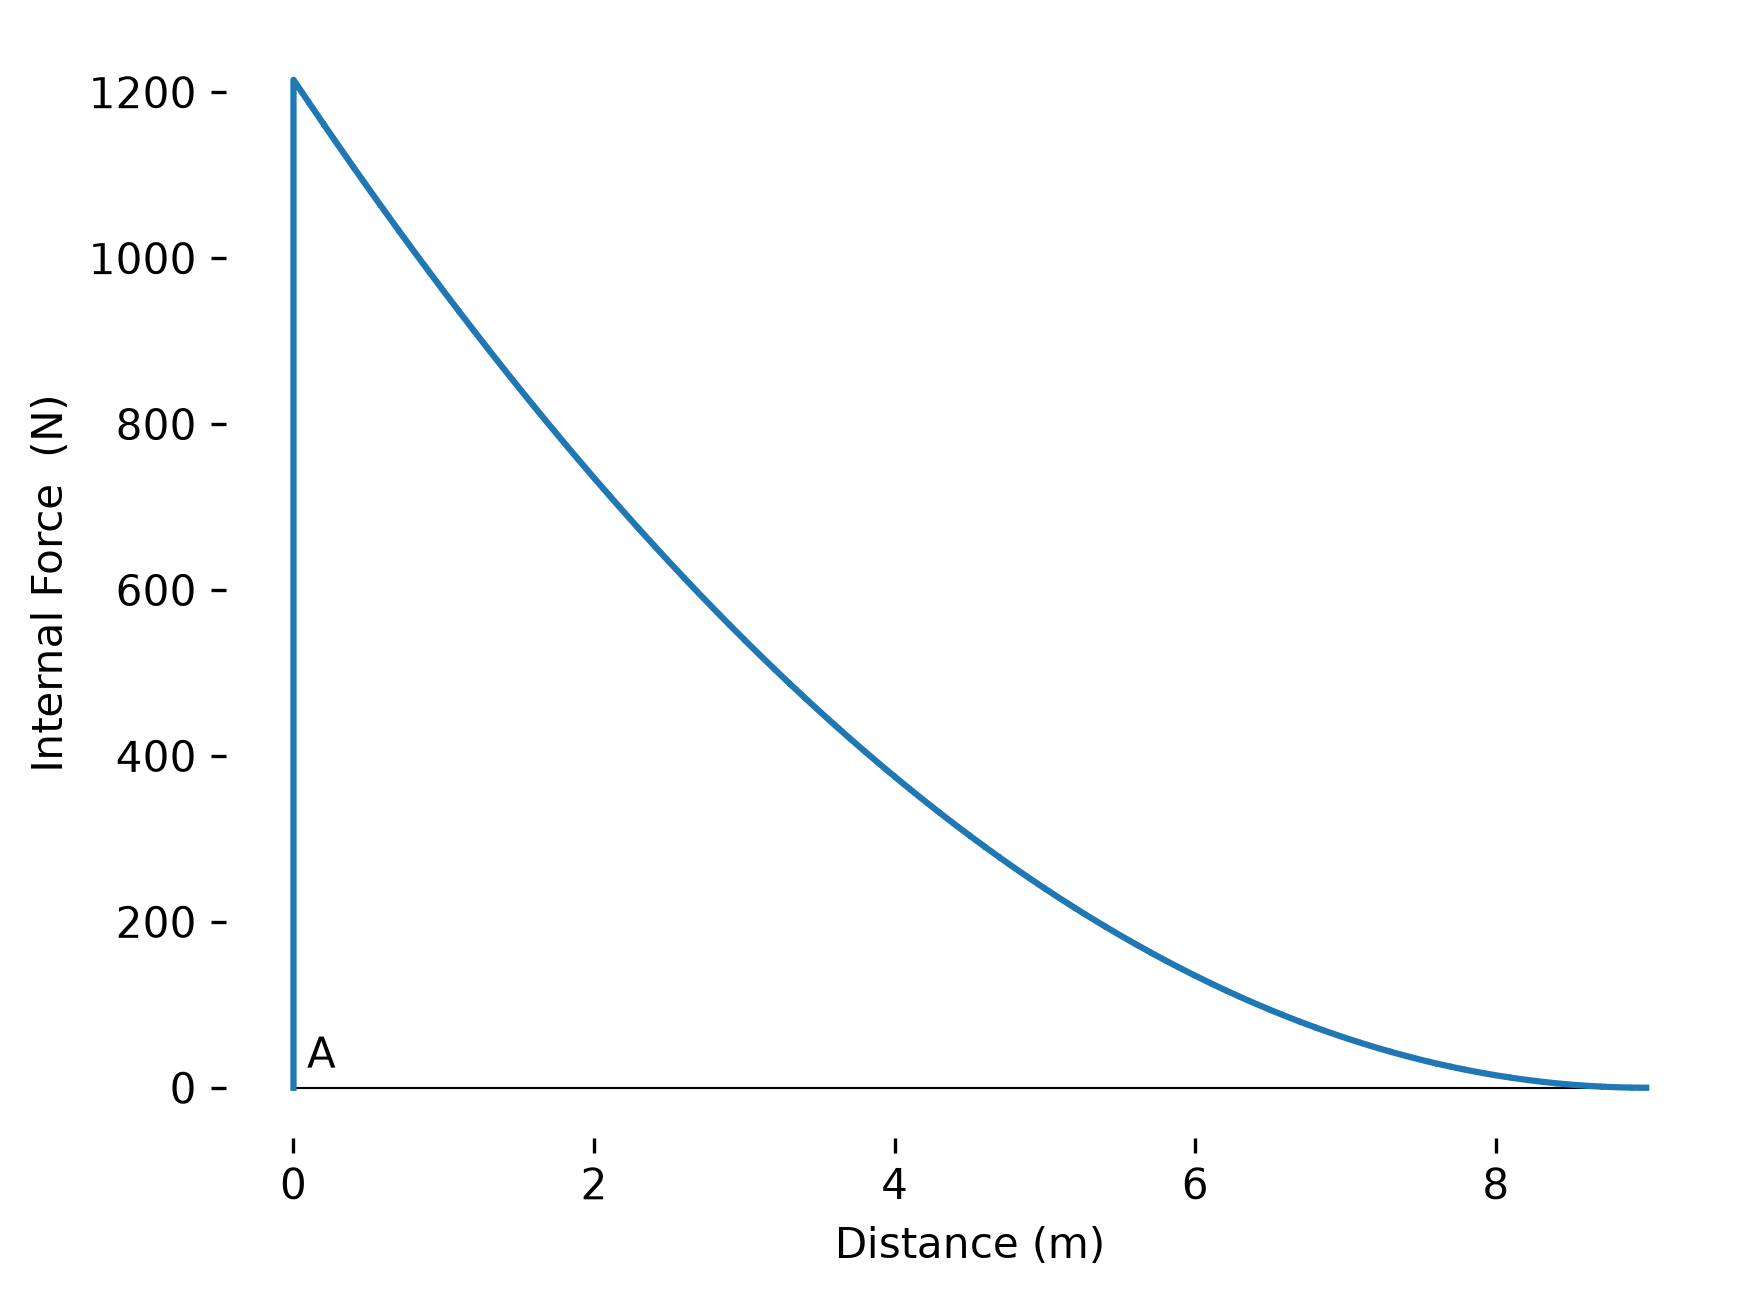

In [6]:
ps.plotShear(beam, scale=1, yunit="N")
plt.show()

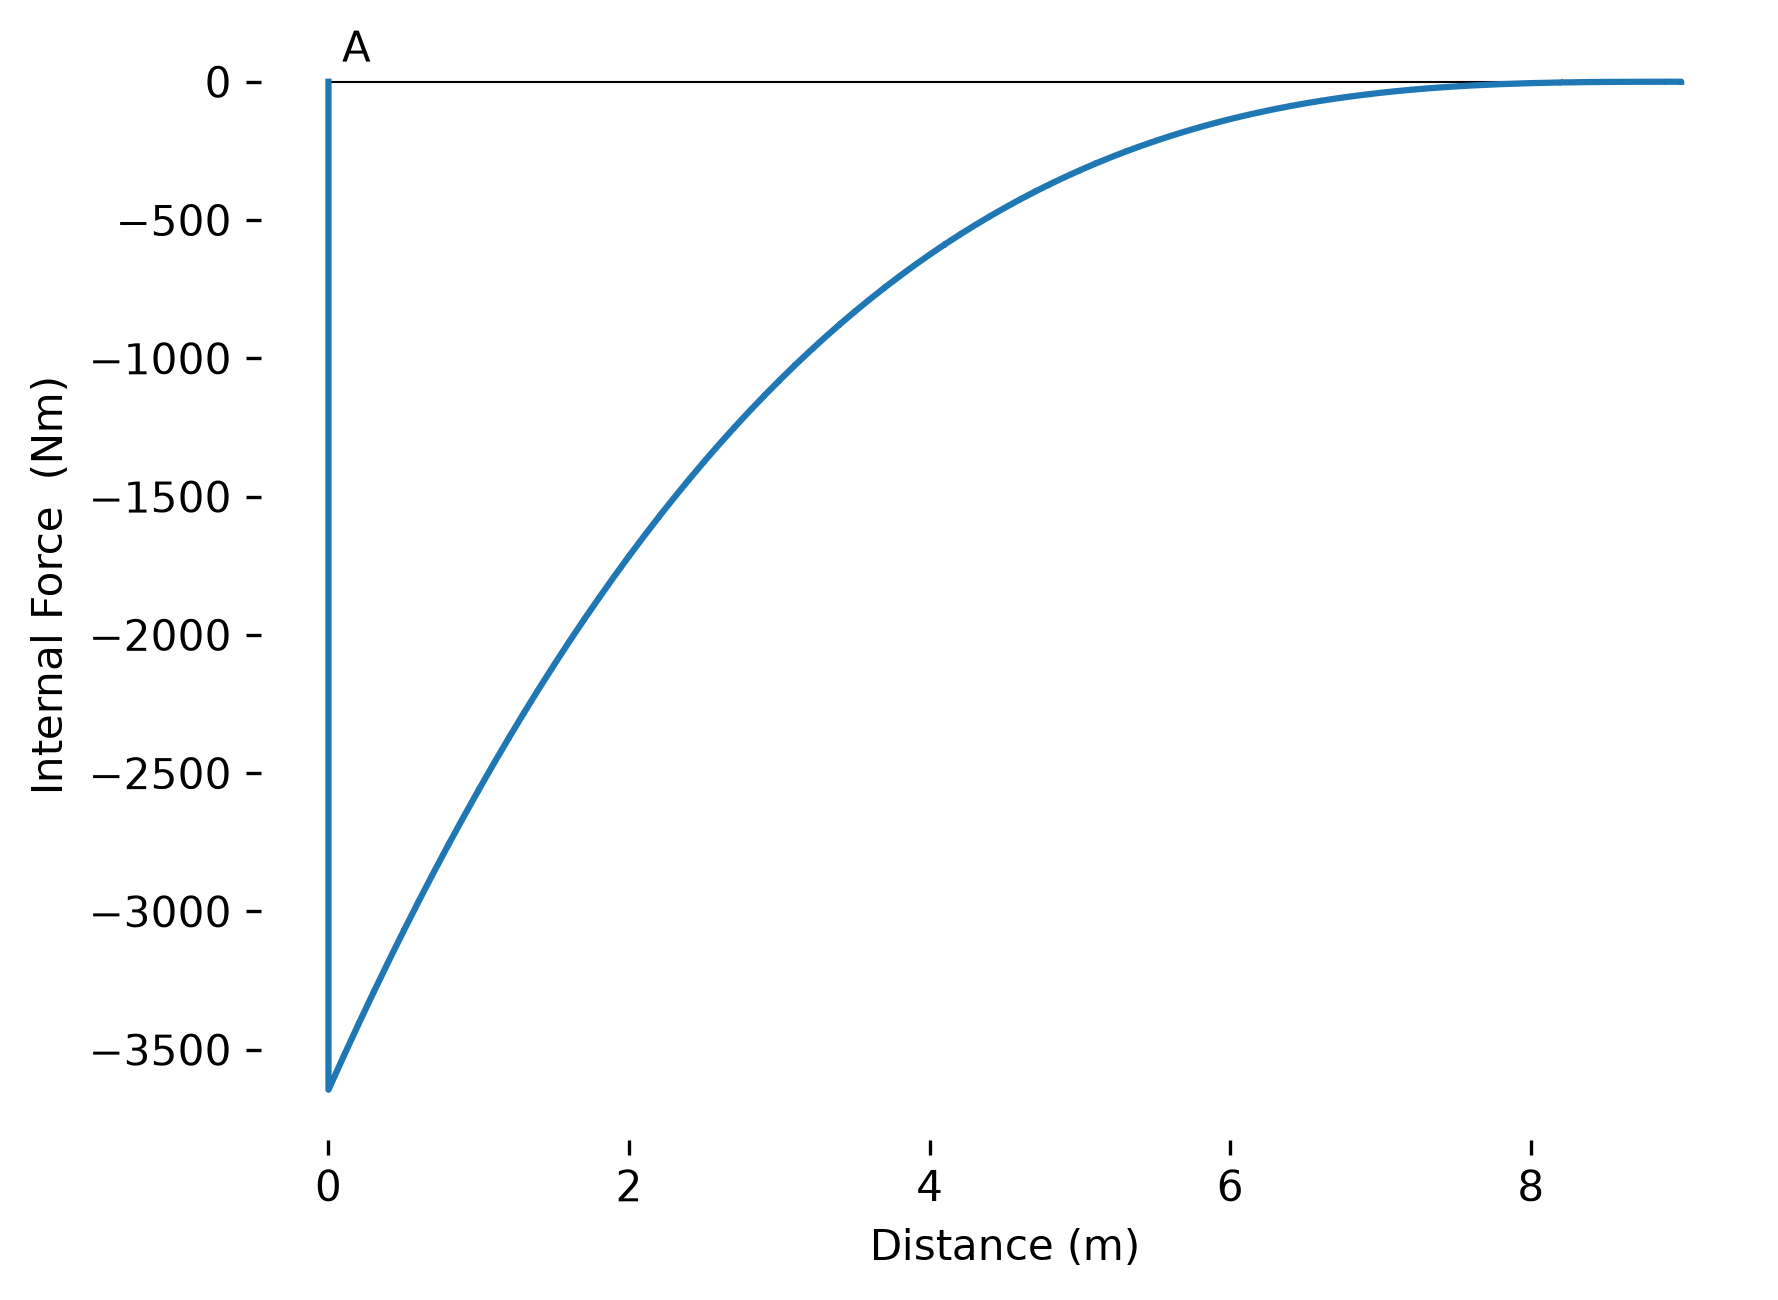

In [7]:
ps.plotMoment(beam, scale=-1, yunit="Nm")
plt.show()

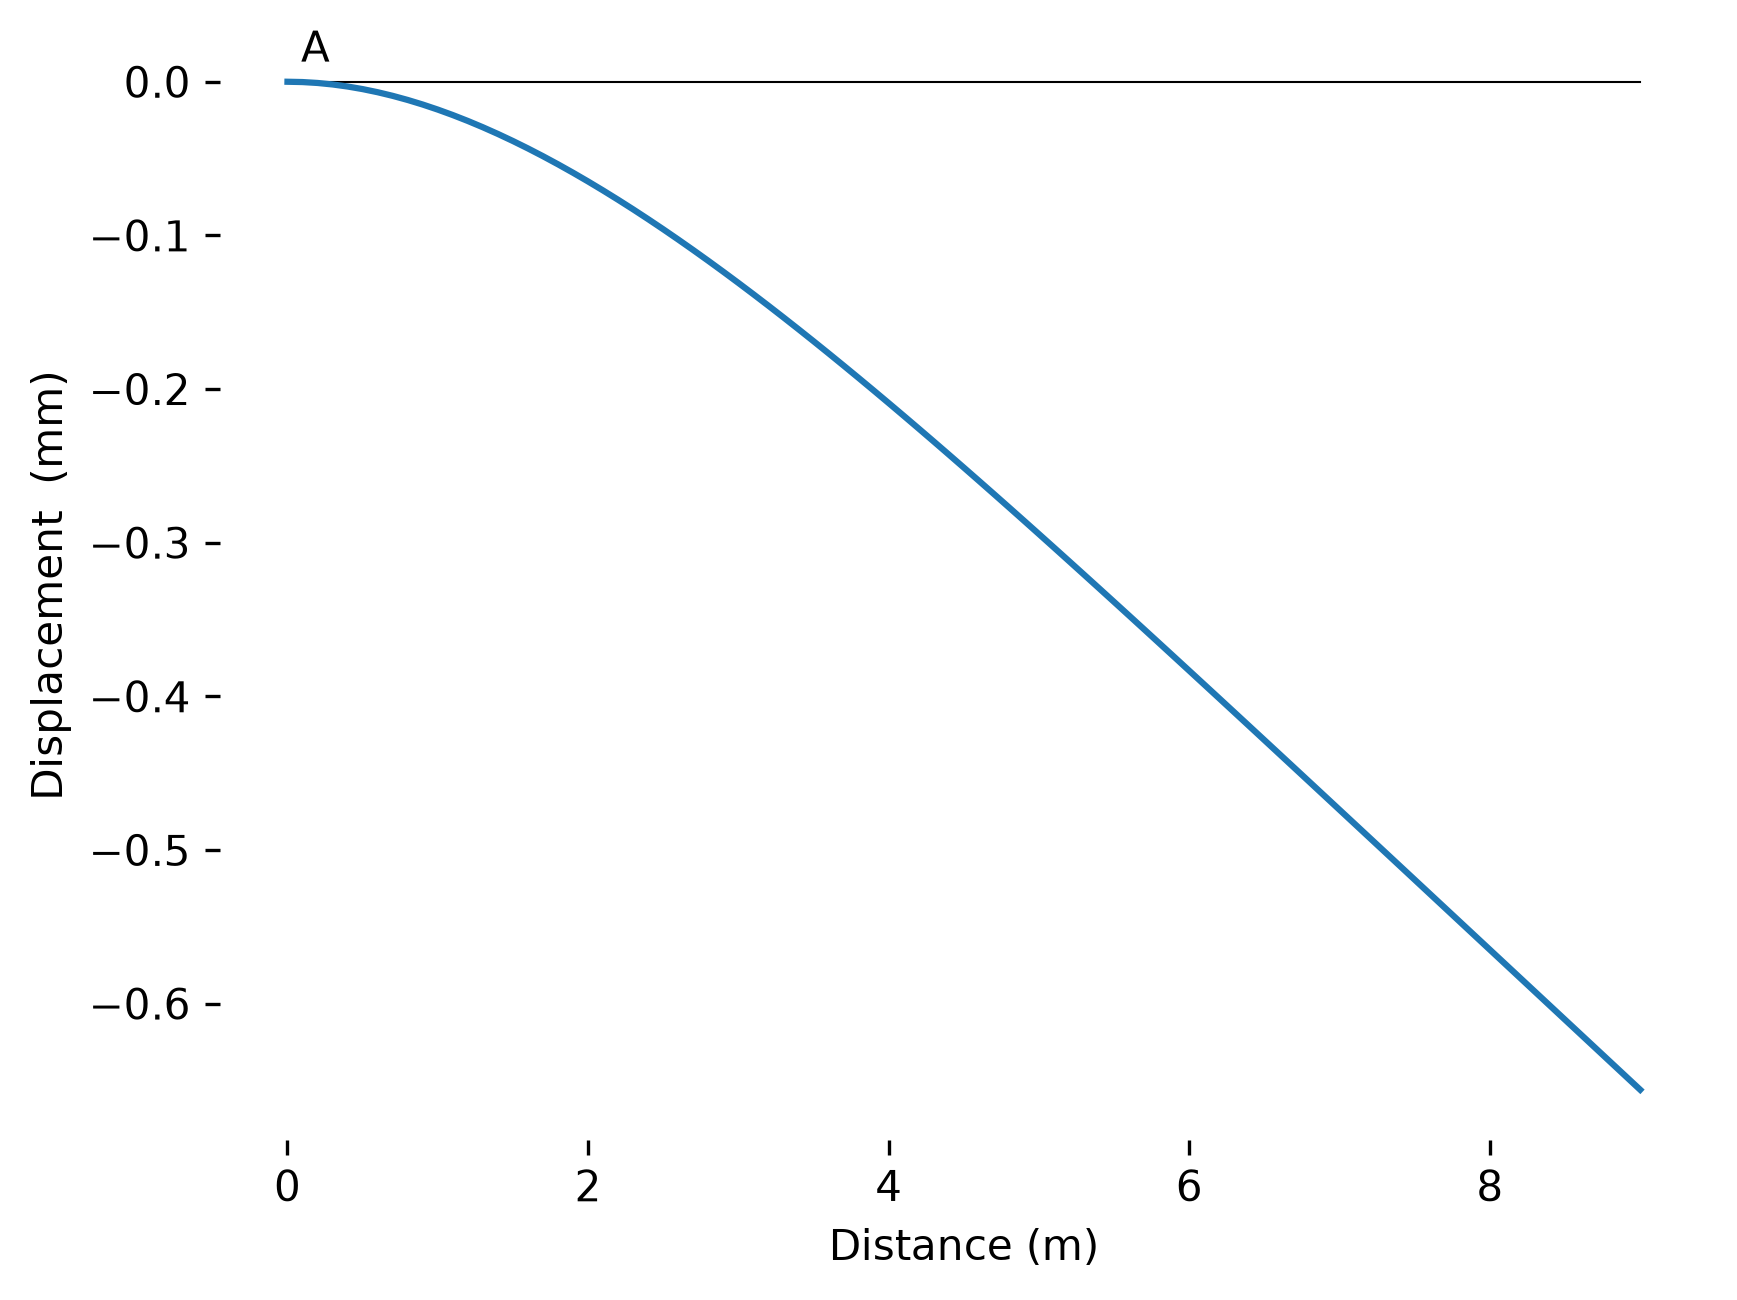

In [8]:
ps.plotDisp(beam, scale=1000, yunit="mm")
plt.show()

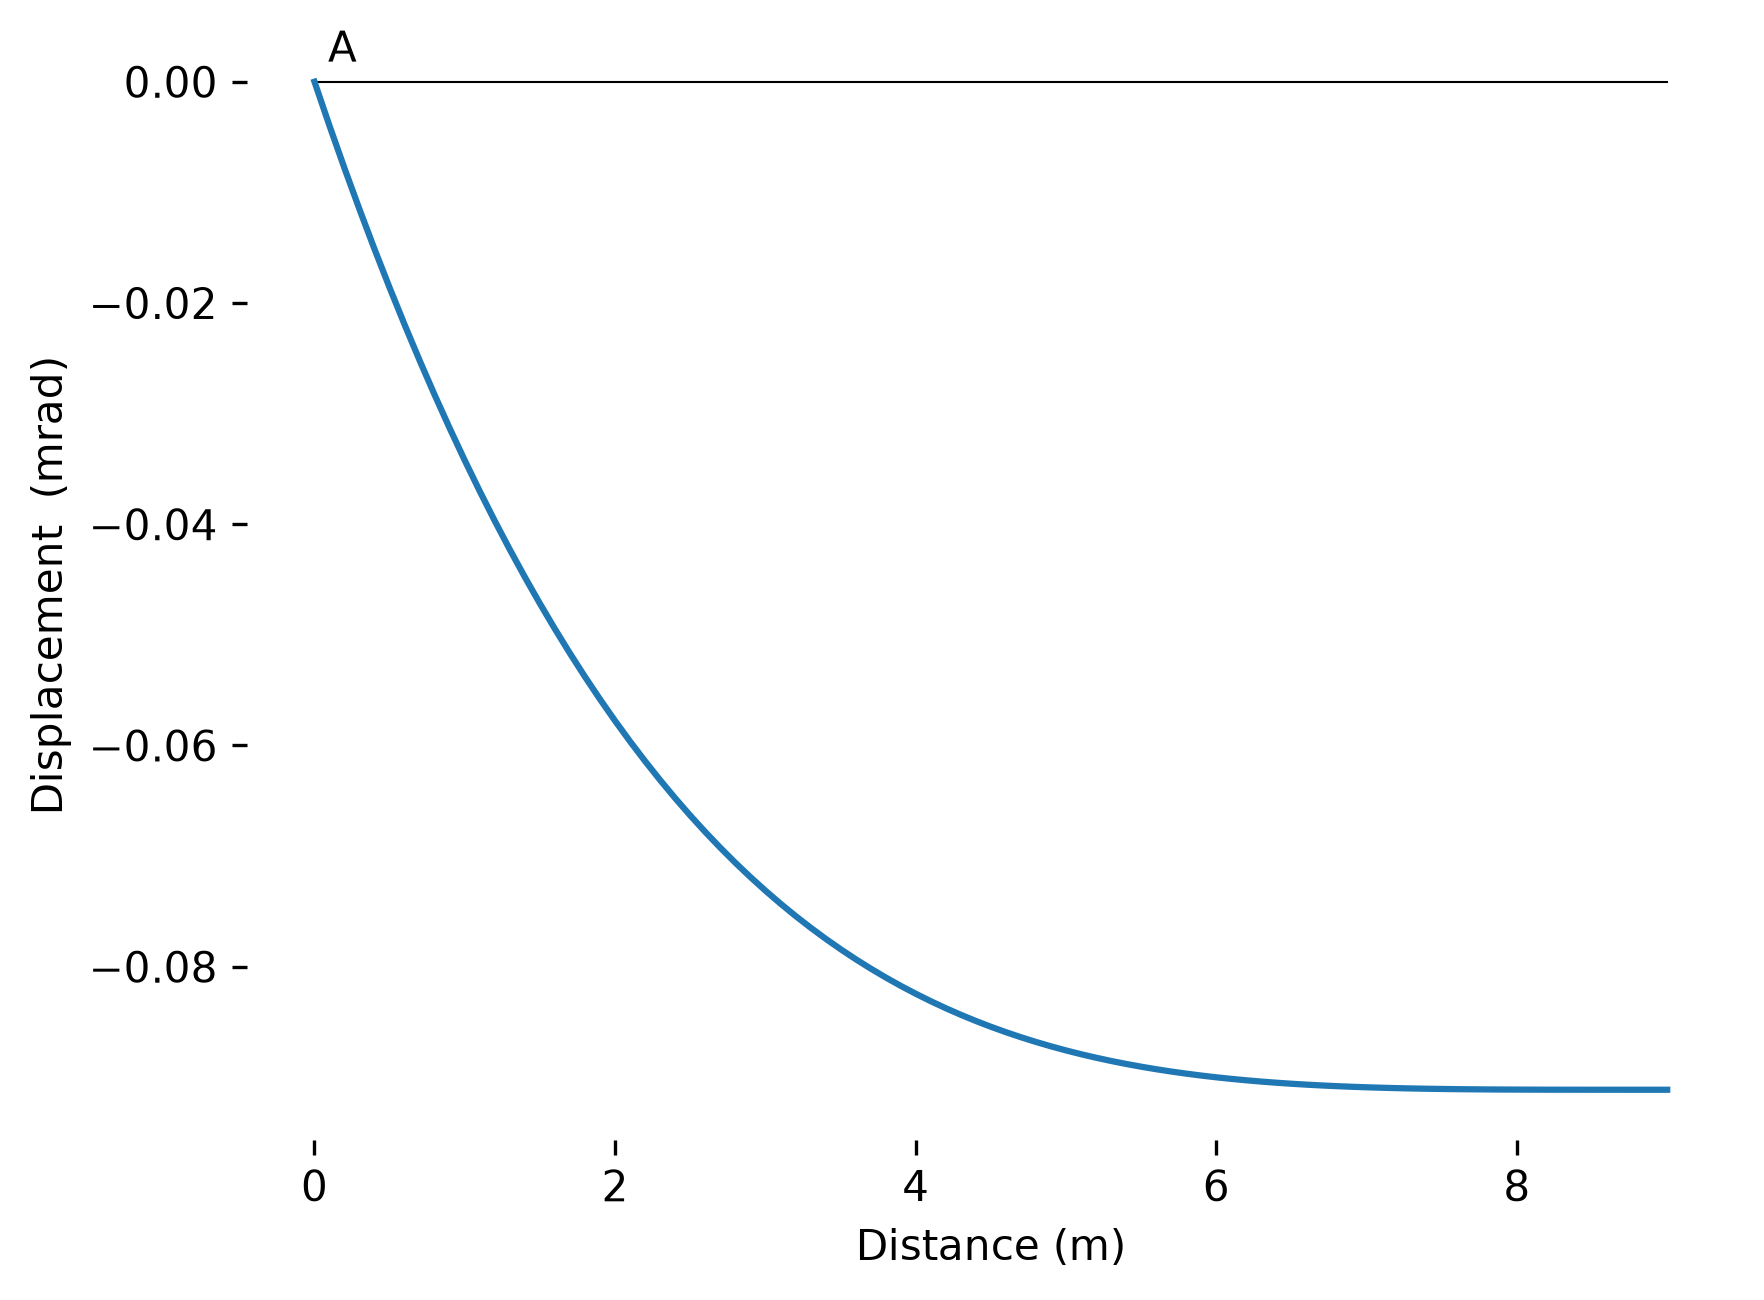

In [9]:
ps.plotRotation(beam, scale=1000, yunit="mrad")
plt.show()

## Check against the closed form

For a cantilever fixed at `x = 0` carrying `w(x) = q0 * (1 - x/L)`:

| quantity | closed form |
|---|---|
| resultant load `W` | `q0*L/2` |
| root shear `V(0)` | `q0*L/2` |
| root moment `M(0)` | `q0*L^2/6` |
| tip deflection | `q0*L^4/(30*EI)` |
| tip rotation | `q0*L^3/(24*EI)` |

In [10]:
import math

checks = [
    # label                          PlaneSections          closed form         formula
    ("reaction Fy [N]",              abs(Fy_r),             q0 * L / 2,         "q0*L/2"),
    ("root moment M(0) [N*m]",       abs(M_r),              q0 * L**2 / 6,      "q0*L^2/6"),
    ("root shear V(0) [N]",          abs(r["V"][0]),        q0 * L / 2,         "q0*L/2"),
    ("tip deflection [mm]",          abs(r["uy"][-1]) * 1e3, q0 * L**4 / (30 * EI) * 1e3, "q0*L^4/(30*EI)"),
    ("tip deflection d*EI [N*m3]",   abs(r["uy"][-1] * EI), q0 * L**4 / 30,     "q0*L^4/30"),
    ("tip rotation phi*EI [N*m2]",   abs(r["rot"][-1] * EI), q0 * L**3 / 24,    "q0*L^3/24"),
]

header = f"{'quantity':<30}{'PlaneSections':>16}{'closed form':>15}   {'formula':<16}"
print(header)
print("-" * len(header))

all_ok = True
for label, fem, exact, formula in checks:
    passed = math.isclose(fem, exact, rel_tol=1e-6)
    all_ok = all_ok and passed
    print(f"{label:<30}{fem:>16.4f}{exact:>15.4f}   {formula:<16}{'OK' if passed else 'FAIL'}")

print("-" * len(header))
print("all checks passed" if all_ok else "MISMATCH -- check the model")

quantity                         PlaneSections    closed form   formula         
--------------------------------------------------------------------------------
reaction Fy [N]                      1215.0000      1215.0000   q0*L/2          OK
root moment M(0) [N*m]               3645.0000      3645.0000   q0*L^2/6        OK
root shear V(0) [N]                  1215.0000      1215.0000   q0*L/2          OK
tip deflection [mm]                     0.6561         0.6561   q0*L^4/(30*EI)  OK
tip deflection d*EI [N*m3]          59048.9999     59049.0000   q0*L^4/30       OK
tip rotation phi*EI [N*m2]           8201.2500      8201.2500   q0*L^3/24       OK
--------------------------------------------------------------------------------
all checks passed


## Shear and moment at a specific location

Because the nodes sit every 0.1 m, whole-metre stations land exactly on nodes, and PyNite
resolves the linear element load exactly -- so these are exact values, not interpolations.
This is the same table produced by the anaStruct notebook, and the numbers agree.

Worth noting: the **deflection** at an interior station comes out exact here, whereas the
anaStruct notebook is ~0.05% off at the same point. anaStruct recovers deflection by
numerically integrating `M/EI` along the element, while PlaneSections reads it straight
off the FEM displacement DOF at the node.

In [11]:
def at_station(r, x, tol=1e-9):
    """Results at station x. Requires a node at x (raises if there is not one)."""
    hit = np.isclose(r["x"], x, atol=tol)
    if not hit.any():
        raise ValueError(f"no node at x = {x}; nearest is {r['x'][np.argmin(abs(r['x'] - x))]}")
    i = int(np.argmax(hit))
    return {"x": x, "V": r["V"][i], "M": r["M"][i], "uy": r["uy"][i], "rot": r["rot"][i]}


x_q = 3.0
s_q = 1.0 - x_q / L
q_at = at_station(r, x_q)

print(f"at x = {x_q:g} m from the fixed root")
print()
print(f"{'':<22}{'PlaneSections':>16}{'closed form':>15}")
print("-" * 53)
print(f"{'shear |V| [N]':<22}{abs(q_at['V']):>16.4f}{q0 * L * s_q**2 / 2:>15.4f}")
print(f"{'moment |M| [N*m]':<22}{abs(q_at['M']):>16.4f}{q0 * L**2 * s_q**3 / 6:>15.4f}")
print(f"{'deflection d*EI':<22}{q_at['uy'] * EI:>16.4f}"
      f"{-q0 * x_q**2 * (10*L**3 - 10*L**2*x_q + 5*L*x_q**2 - x_q**3) / (120*L):>15.4f}")

at x = 3 m from the fixed root

                         PlaneSections    closed form
-----------------------------------------------------
shear |V| [N]                 540.0000       540.0000
moment |M| [N*m]             1080.0000      1080.0000
deflection d*EI            -11785.5000    -11785.5000


In [12]:
stations = np.arange(0.0, L + 1e-9, 1.0)
s_all = 1.0 - stations / L
V_exact = q0 * L * s_all**2 / 2
M_exact = q0 * L**2 * s_all**3 / 6

header = f"{'x [m]':>7}{'|V| [N]':>12}{'exact':>12}{'|M| [N*m]':>14}{'exact':>14}"
print(header)
print("-" * len(header))
for xi, Ve, Me in zip(stations, V_exact, M_exact):
    st = at_station(r, xi)
    print(f"{xi:>7.2f}{abs(st['V']):>12.3f}{Ve:>12.3f}{abs(st['M']):>14.3f}{Me:>14.3f}")

  x [m]     |V| [N]       exact     |M| [N*m]         exact
-----------------------------------------------------------
   0.00    1215.000    1215.000      3645.000      3645.000
   1.00     960.000     960.000      2560.000      2560.000
   2.00     735.000     735.000      1715.000      1715.000
   3.00     540.000     540.000      1080.000      1080.000
   4.00     375.000     375.000       625.000       625.000
   5.00     240.000     240.000       320.000       320.000
   6.00     135.000     135.000       135.000       135.000
   7.00      60.000      60.000        40.000        40.000
   8.00      15.000      15.000         5.000         5.000
   9.00       0.000       0.000         0.000         0.000


## What if you only had a constant distributed load?

`addLinLoadVertical` is new-ish. Plenty of tools -- and the older PlaneSections API used
in your other notebook -- only offer a **constant** `q` over a span, so the taper has to be
approximated by `N` strips, each carrying the load intensity at its own midpoint.

Sampling at the midpoint makes each strip's resultant exactly right, so the **total load is
exact for any `N`** and the root shear comes out at 1215 N every time. What the staircase
gets wrong is *where* the load sits, so the error shows up in the **moment**.

In [13]:
def strip_model(n_strips):
    """Triangular load approximated by n constant-q strips, sampled at strip midpoints."""
    edges = np.linspace(0, L, n_strips + 1)
    # make sure every strip boundary is also a node
    nodes = np.unique(np.concatenate([np.linspace(0, L, 91), edges]))

    b = ps.EulerBeam2D(nodes, section=section)
    b.setFixity(0.0, ps.FixityTypes2D.getFixed())
    for x1, x2 in zip(edges[:-1], edges[1:]):
        q_mid = -q0 * (1.0 - 0.5 * (x1 + x2) / L)
        b.addDistLoadVertical(x1, x2, q_mid)

    ps.PyNiteAnalyzer2D(b).runAnalysis()
    return node_results(b)


V_ex = q0 * L / 2
M_ex = q0 * L**2 / 6

counts = [3, 6, 9, 18, 36, 72]
errs = []

header = f"{'strips':>7}{'V(0) [N]':>12}{'err %':>10}{'M(0) [N*m]':>13}{'err %':>10}"
print(header)
print("-" * len(header))
for n in counts:
    rn = strip_model(n)
    eV = 100 * (abs(rn["V"][0]) - V_ex) / V_ex
    eM = 100 * (abs(rn["M"][0]) - M_ex) / M_ex
    errs.append(abs(eM))
    print(f"{n:>7}{abs(rn['V'][0]):>12.4f}{eV:>10.4f}{abs(rn['M'][0]):>13.4f}{eM:>10.4f}")

print("-" * len(header))
print(f"{'exact':>7}{V_ex:>12.4f}{0.0:>10.4f}{M_ex:>13.4f}{0.0:>10.4f}")
print(f"{'linear':>7}{abs(r['V'][0]):>12.4f}"
      f"{100 * (abs(r['V'][0]) - V_ex) / V_ex:>10.4f}{abs(r['M'][0]):>13.4f}"
      f"{100 * (abs(r['M'][0]) - M_ex) / M_ex:>10.4f}")

 strips    V(0) [N]     err %   M(0) [N*m]     err %
----------------------------------------------------
      3   1215.0000   -0.0000    3847.5000    5.5556
      6   1215.0000   -0.0000    3695.6250    1.3889
      9   1215.0000   -0.0000    3667.5000    0.6173
     18   1215.0000   -0.0000    3650.6250    0.1543
     36   1215.0000   -0.0000    3646.4062    0.0386
     72   1215.0000   -0.0000    3645.3515    0.0096
----------------------------------------------------
  exact   1215.0000    0.0000    3645.0000    0.0000
 linear   1215.0000   -0.0000    3645.0000   -0.0000


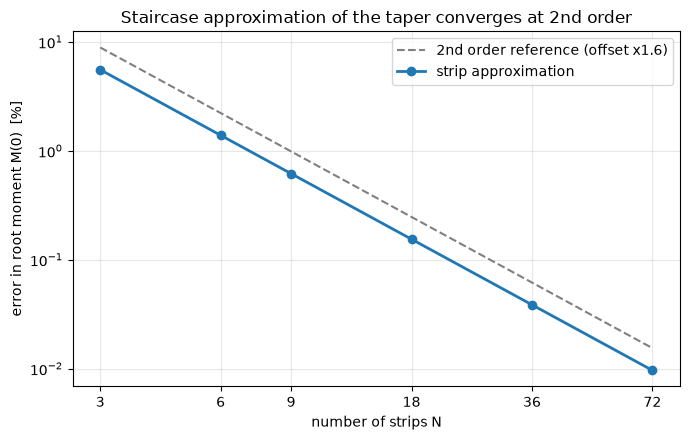

Doubling the strip count quarters the error -- textbook 2nd-order convergence.
Even 72 strips is still 0.0096% off, while addLinLoadVertical
is exact with a single load object.


In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))

# Second-order reference slope, offset a little so it does not hide under the data
# (the two lie on top of each other almost exactly, which is the point).
ref = errs[0] * (np.array(counts, dtype=float) / counts[0]) ** -2.0
ax.loglog(counts, ref * 1.6, "--", color="grey", lw=1.5,
          label="2nd order reference (offset x1.6)")
ax.loglog(counts, errs, "o-", lw=2, label="strip approximation")

ax.set_xlabel("number of strips N")
ax.set_ylabel("error in root moment M(0)  [%]")
ax.set_title("Staircase approximation of the taper converges at 2nd order")
ax.set_xticks(counts)
ax.set_xticklabels([str(c) for c in counts])
ax.minorticks_off()
ax.grid(True, which="major", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("Doubling the strip count quarters the error -- textbook 2nd-order convergence.")
print(f"Even {counts[-1]} strips is still {errs[-1]:.4f}% off, while addLinLoadVertical")
print("is exact with a single load object.")

## API notes for planesections 1.4.2

Differences that bite when running older PlaneSections code (including your
`Beam_bending_shear_displacement_PlaneSections.ipynb`):

| older API | 1.4.2 |
|---|---|
| `ps.OpenSeesAnalyzer2D(beam)` | **`ps.PyNiteAnalyzer2D(beam)`** -- backend moved from OpenSeesPy to PyNiteFEA |
| constant `q` only | **`addLinLoadVertical(x1, x2, [q1, q2])`** for tapered loads |

Other things worth knowing:

* **`ps.SectionBasic2D` is broken in 1.4.2** -- constructing it raises
  `AttributeError: 'super' object has no attribute '__post_init__'`. That is the natural
  way to set `E` and `Iz` directly (e.g. to normalize `EI = 1`), so until it is fixed use
  `ps.SectionRectangle` and work with a real section, as done here.
* **`getSFD()` / `getBMD()` return `2 * Nnodes` values**, each node duplicated
  (left value, right value) so jumps plot correctly. Index 0 is the baseline, not the
  value at `x = 0`. Use `[1::2]`.
* **`ps.getVertDisp(beam)` returns `(disp, xcoords)`** in that order -- displacement
  first. Unpacking it the other way round silently hands you the x coordinates.
* Reactions are on the node: `beam.nodes[i].rFrc` -> `[Fx, Fy, M]`.

## Summary

| quantity | value |
|---|---|
| span `L` | 9 m |
| load | 270 N/m at the root, linear to 0 N/m at the tip |
| resultant `W` | **1215 N** at 3.0 m from the root |
| reaction at the root | **1215 N** upward |
| fixing moment at the root | **3645 N*m** hogging |
| shear at x = 3 m | **540 N** |
| moment at x = 3 m | **1080 N*m** |
| tip deflection (300x200 steel) | **0.656 mm** |
| tip deflection, normalized | **59049 / EI** m |
| tip rotation, normalized | **8201.25 / EI** rad |

Agrees with the anaStruct notebook and the closed form to better than 1e-6 relative.